In [2]:
pip install factor_analyzer seaborn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42714 sha256=ee72f1b3daaeddbf35dcf19ddf2eb5f9a4dd12a295a9f992f3b913db84f651b0
  Stored in directory: c:\users\pandya anand\appdata\local\pip\cache\wheels\87\6e\8f\914f20e0242ee0214e5c8336031a2fab12e632e4695fbb7276
Successfully built factor_analyzer
Note: you may need to restart the kernel to use updated packages.


In [9]:
# Cell 1: Settings, load folder, resample, returns
import re, glob, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from factor_analyzer import FactorAnalyzer, calculate_bartlett_sphericity, calculate_kmo
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ===== SETTINGS =====
FOLDER      = r"C:\Users\Pandya Anand\Downloads\x"
TF          = "1min"     # "1min","5min","15min","1h","4h","1D","1W","ME"
PRICES      = True        # True = prices, False = already returns
KEEP_COL    = "close"     # for multi-column files keep only this column (None = keep all)
DIFF_COLS   = []          # yields/spreads use difference, e.g. ["us10y_yield"]
MAX_MISSING = None        # None = auto (0.8 intraday, 0.2 daily+)
DUP_CORR    = 0.95        # drop columns more correlated than this
# ====================

INTRADAY = TF.lower().endswith(("min", "h"))
if MAX_MISSING is None:
    MAX_MISSING = 0.8 if INTRADAY else 0.2

def clean_name(s):
    return re.sub(r"[^a-z0-9]+", "_", str(s).strip().lower()).strip("_")

frames = []
for path in sorted(glob.glob(os.path.join(FOLDER, "*.csv"))):
    fname = clean_name(os.path.splitext(os.path.basename(path))[0])
    d = pd.read_csv(path, index_col=0)
    d.columns = [clean_name(c) for c in d.columns]
    d.index = pd.to_datetime(d.index, errors="coerce", utc=True).tz_localize(None)
    d = d[d.index.notna()].select_dtypes(include=[np.number])
    if d.empty:
        print("Skipped (no numeric):", fname); continue

    # OHLC fix: keep only one column per file
    if KEEP_COL and d.shape[1] > 1:
        if KEEP_COL in d.columns:
            d = d[[KEEP_COL]]
        else:
            print(f"{fname}: '{KEEP_COL}' not found, keeping all {list(d.columns)}")

    d = d[~d.index.duplicated(keep="last")].sort_index()
    d = d.resample(TF).last() if PRICES else d.resample(TF).sum(min_count=1)
    d.columns = [fname] if d.shape[1] == 1 else [f"{fname}_{c}" for c in d.columns]
    frames.append(d)
    print(f"{fname}: {d.shape}, {d.index.min()} to {d.index.max()}")


df = pd.concat(frames, axis=1, join="outer").sort_index()
print("Merged grid:", df.shape)

# 1. Remove bins where most series have no price (nights, weekends, holidays)
df = df[df.notna().mean(axis=1) >= 0.5]
print("After removing empty bins:", df.shape)

# 2. Fill short price gaps (max 2 bars)
df = df.ffill(limit=2)

# 3. Returns
if PRICES:
    ret = np.log(df.where(df > 0)).diff()
    for c in DIFF_COLS:
        if c in df: ret[c] = df[c].diff()
else:
    ret = df.copy()
ret = ret.replace([np.inf, -np.inf], np.nan)

# 4. Missing report for ALL columns
miss = ret.isna().mean()
print("\nMissing % per column:\n", (miss.sort_values(ascending=False) * 100).round(1).to_string())

# 5. Drop sparse columns, then rows with gaps
ret = ret.loc[:, miss <= MAX_MISSING]
assert ret.shape[1] >= 4, "Too few columns survived. Read the Missing % table and the file date ranges above."
ret = ret.dropna()

# 6. Remove time-of-day volatility pattern (intraday only)
if INTRADAY:
    ret = ret / ret.groupby(ret.index.time).transform("std")

df = ret.replace([np.inf, -np.inf], np.nan).dropna()
print("\nFinal shape:", df.shape, "| TF:", TF)

aapl_1m: (40710, 1), 2026-08-31 13:30:00 to 2026-09-28 19:59:00
bac_1m: (40710, 1), 2026-08-31 13:30:00 to 2026-09-28 19:59:00
nvda_1m: (40711, 1), 2026-08-31 13:29:00 to 2026-09-28 19:59:00
pltr_1m: (40710, 1), 2026-08-31 13:30:00 to 2026-09-28 19:59:00
tsla_1m: (40711, 1), 2026-08-31 13:29:00 to 2026-09-28 19:59:00
Merged grid: (40711, 5)
After removing empty bins: (7811, 5)

Missing % per column:
 aapl_1m    0.0
bac_1m     0.0
nvda_1m    0.0
pltr_1m    0.0
tsla_1m    0.0

Final shape: (7799, 5) | TF: 1min


In [10]:
# Cell 2: Clip, standardize, clean (with step-by-step checks)
print("Start:", df.shape)

# 1. Duplicate column names would break the filters
dupnames = df.columns[df.columns.duplicated()].tolist()
print("Duplicate column names:", dupnames)
df = df.loc[:, ~df.columns.duplicated()].copy()

# 2. Zero-return share and std per column
print("\nShare of zero returns (top):\n", (df == 0).mean().sort_values(ascending=False).head(8).round(3))
print("\nStd per column (lowest):\n", df.std().sort_values().head(8))

# 3. Clip outliers per column, only if it keeps some variance
lo, hi = df.quantile(0.01), df.quantile(0.99)
for c in df.columns:
    cl = df[c].clip(lo[c], hi[c])
    if cl.std() > 0:
        df[c] = cl

# 4. Drop constant columns
df = df.loc[:, df.std() > 0]
print("\nAfter clip + constant filter:", df.shape)

# 5. Standardize
X = (df - df.mean()) / df.std()

# 6. Drop near-duplicates (keeps the first of each group)
c_abs = X.corr().abs().values
keep = []
for i in range(c_abs.shape[0]):
    if all(c_abs[i, j] <= DUP_CORR for j in keep):
        keep.append(i)
print("Dropping near-duplicates:", [X.columns[i] for i in range(c_abs.shape[0]) if i not in keep])
X = X.iloc[:, keep]

# 7. Health check
corr = X.corr()
print("\nShape:", X.shape)
assert X.shape[1] >= 4, f"Only {X.shape[1]} columns left, read the prints above"
print("Rank:", np.linalg.matrix_rank(corr.values), "of", corr.shape[0])
print("Condition number:", f"{np.linalg.cond(corr.values):.1e}", "(>1e10 = near-singular)")
assert X.shape[0] > 5 * X.shape[1], f"Too few rows ({X.shape[0]}) for {X.shape[1]} columns"

Start: (7799, 5)
Duplicate column names: []

Share of zero returns (top):
 bac_1m     0.190
nvda_1m    0.041
pltr_1m    0.034
aapl_1m    0.028
tsla_1m    0.017
dtype: float64

Std per column (lowest):
 aapl_1m    1.001747
tsla_1m    1.004264
bac_1m     1.004382
nvda_1m    1.005116
pltr_1m    1.007679
dtype: float64

After clip + constant filter: (7799, 5)
Dropping near-duplicates: []

Shape: (7799, 5)
Rank: 5 of 5
Condition number: 2.0e+00 (>1e10 = near-singular)


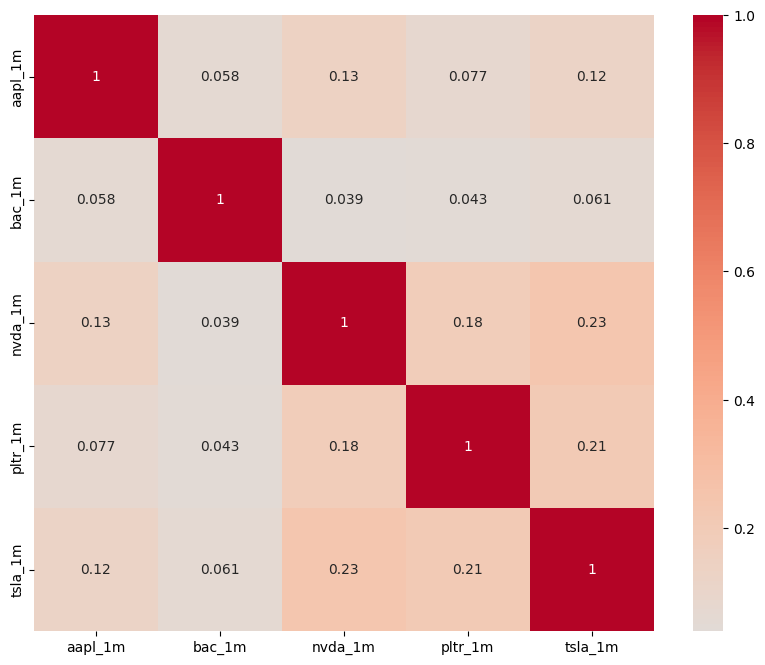

Weakly correlated vars: ['aapl_1m', 'bac_1m', 'nvda_1m', 'pltr_1m', 'tsla_1m']


In [11]:
# Cell 3: Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=len(corr) < 15)
plt.show()

weak = corr.abs().apply(lambda c: (c.drop(c.name) > 0.3).sum()) == 0
print("Weakly correlated vars:", list(weak[weak].index))

In [12]:
# Cell 4: Bartlett + KMO (NaN-safe)
if len(X) < 20000:
    chi2, p = calculate_bartlett_sphericity(X)
    print(f"Bartlett: chi2={chi2:.1f}, p={p:.4f}")
else:
    print("Bartlett skipped (too many rows, p always ~0). Using KMO.")

while True:
    kmo_per_var, kmo_total = calculate_kmo(X)
    if np.isnan(kmo_total):
        raise ValueError("KMO is NaN: matrix singular. Check duplicates/rank in Cell 2.")
    low = X.columns[kmo_per_var < 0.5]
    if len(low) == 0 or X.shape[1] <= 4:
        break
    print("Dropping (KMO<0.5):", list(low))
    X = X.drop(columns=low)

print(f"Overall KMO: {kmo_total:.3f}")
assert kmo_total > 0.6, f"KMO {kmo_total:.3f} too low for factor analysis"

Bartlett: chi2=1221.9, p=0.0000
Overall KMO: 0.628


C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


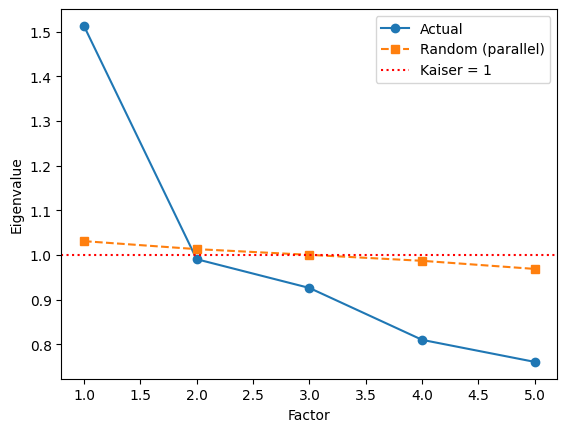

Kaiser: 1 | Parallel: 1


In [13]:
# Cell 5: Number of factors (Kaiser, scree, parallel analysis)
Xs = X.sample(20000, random_state=1) if len(X) > 20000 else X
n, k = Xs.shape
n_sim = 100 if n < 5000 else 20

fa0 = FactorAnalyzer(n_factors=k, rotation=None).fit(Xs)
ev, _ = fa0.get_eigenvalues()
rand_ev = np.mean([np.linalg.eigvalsh(np.corrcoef(np.random.randn(n, k), rowvar=False))[::-1]
                   for _ in range(n_sim)], axis=0)

plt.plot(range(1, k + 1), ev, "o-", label="Actual")
plt.plot(range(1, k + 1), rand_ev, "s--", label="Random (parallel)")
plt.axhline(1, color="r", ls=":", label="Kaiser = 1")
plt.xlabel("Factor"); plt.ylabel("Eigenvalue"); plt.legend(); plt.show()

n_factors = max(1, int((ev > rand_ev).sum()))
print("Kaiser:", int((ev > 1).sum()), "| Parallel:", n_factors)

In [14]:
# Cell 6: Run factor analysis
# rotation: "promax"/"oblimin" = correlated factors, "varimax" = uncorrelated
ROTATION = "promax"
fa = FactorAnalyzer(n_factors=n_factors, method="principal", rotation=ROTATION).fit(X)

cols = [f"F{i+1}" for i in range(n_factors)]
loadings = pd.DataFrame(fa.loadings_, index=X.columns, columns=cols)
print(loadings.round(3))

            F1
aapl_1m  0.453
bac_1m   0.232
nvda_1m  0.658
pltr_1m  0.598
tsla_1m  0.681


C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\factor_analyzer\factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(


Low communality (<0.3): ['aapl_1m', 'bac_1m']
    SS Loadings  Proportion  Cumulative
F1        1.513       0.303       0.303

Strong loadings (>0.4):
            F1
aapl_1m  0.45
bac_1m    NaN
nvda_1m  0.66
pltr_1m  0.60
tsla_1m  0.68


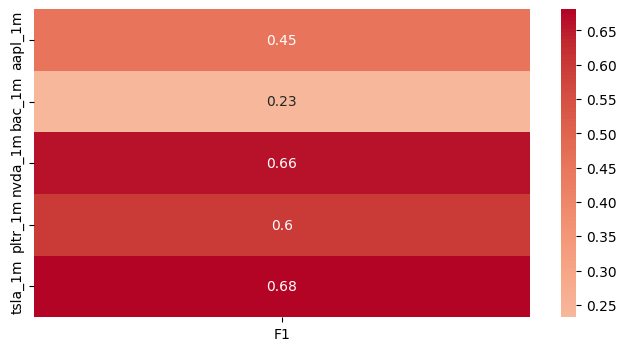

In [15]:
# Cell 7: Interpret
communalities = pd.Series(fa.get_communalities(), index=X.columns)
print("Low communality (<0.3):", list(communalities[communalities < 0.3].index))

var, prop, cum = fa.get_factor_variance()
print(pd.DataFrame({"SS Loadings": var, "Proportion": prop, "Cumulative": cum}, index=cols).round(3))

print("\nStrong loadings (>0.4):\n", loadings.where(loadings.abs() > 0.4).round(2))

plt.figure(figsize=(8, max(4, 0.35 * len(loadings))))
sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0)
plt.show()

In [16]:
# Cell 8: Factor scores (use in VAR / GARCH)
scores = pd.DataFrame(fa.transform(X), index=X.index, columns=cols)
print(scores.head())

# ADF check before VAR
from statsmodels.tsa.stattools import adfuller
for c in cols:
    print(c, "ADF p-value:", round(adfuller(scores[c].dropna())[1], 4))

C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


                           F1
timestamp                    
2026-08-31 13:31:00  0.208896
2026-08-31 13:32:00 -0.632702
2026-08-31 13:33:00  0.485790
2026-08-31 13:34:00 -1.441755
2026-08-31 13:35:00 -1.520428
F1 ADF p-value: 0.0


In [17]:
# Cell 9: Split-sample stability check
half = len(X) // 2
fa_a = FactorAnalyzer(n_factors=n_factors, method="principal", rotation=ROTATION).fit(X.iloc[:half])
fa_b = FactorAnalyzer(n_factors=n_factors, method="principal", rotation=ROTATION).fit(X.iloc[half:])

def congruence(a, b):
    return np.sum(a * b) / np.sqrt(np.sum(a**2) * np.sum(b**2))

for i in range(n_factors):
    best = max(abs(congruence(fa_a.loadings_[:, i], fa_b.loadings_[:, j])) for j in range(n_factors))
    print(f"Factor {i+1} congruence: {best:.3f}  (>0.85 = stable)")

Factor 1 congruence: 0.989  (>0.85 = stable)


C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\factor_analyzer\factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(
C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\Pandya Anand\AppData\Local\Programs\Python\Python313\Lib\site-packages\factor_analyzer\factor_analyzer.py:663: UserWarning: No rotation will be performed when the number of factors equals 1.
  warnings.warn(
